In [95]:
import pandas as pd

df = pd.read_csv('df_labeled_all_final_25.csv')
df.shape

(37569, 20)

In [96]:
df.columns

Index(['id', 'judge', 'decision', 'gender_accused', 'prior_convictions',
       'alcohol', 'precrime_argument', 'has_woman_victim', 'has_man_victim',
       'method', 'motive', 'location', 'prison_term', 'many_victims', 'year',
       'season', 'attempt', 'victim_child_or_helpless', 'cruel',
       'region_name'],
      dtype='object')

In [97]:
df.isna().sum()

id                          0
judge                       0
decision                    0
gender_accused              0
prior_convictions           0
alcohol                     0
precrime_argument           0
has_woman_victim            0
has_man_victim              0
method                      0
motive                      0
location                    0
prison_term                 0
many_victims                0
year                        0
season                      0
attempt                     0
victim_child_or_helpless    0
cruel                       0
region_name                 0
dtype: int64

In [98]:
df.isnull().sum()

id                          0
judge                       0
decision                    0
gender_accused              0
prior_convictions           0
alcohol                     0
precrime_argument           0
has_woman_victim            0
has_man_victim              0
method                      0
motive                      0
location                    0
prison_term                 0
many_victims                0
year                        0
season                      0
attempt                     0
victim_child_or_helpless    0
cruel                       0
region_name                 0
dtype: int64

## Анализ данных для prison_term

In [99]:
import math

df = df[df['prison_term'] != math.inf]

In [100]:
df['prison_term'].head()
df['prison_term'].describe()

count    37558.000000
mean         9.081634
std         51.721612
min          0.200000
25%          7.000000
50%          8.500000
75%         10.000000
max       9999.000000
Name: prison_term, dtype: float64

In [101]:
# import numpy as np

# df['prison_term'] = np.log(df['prison_term'])

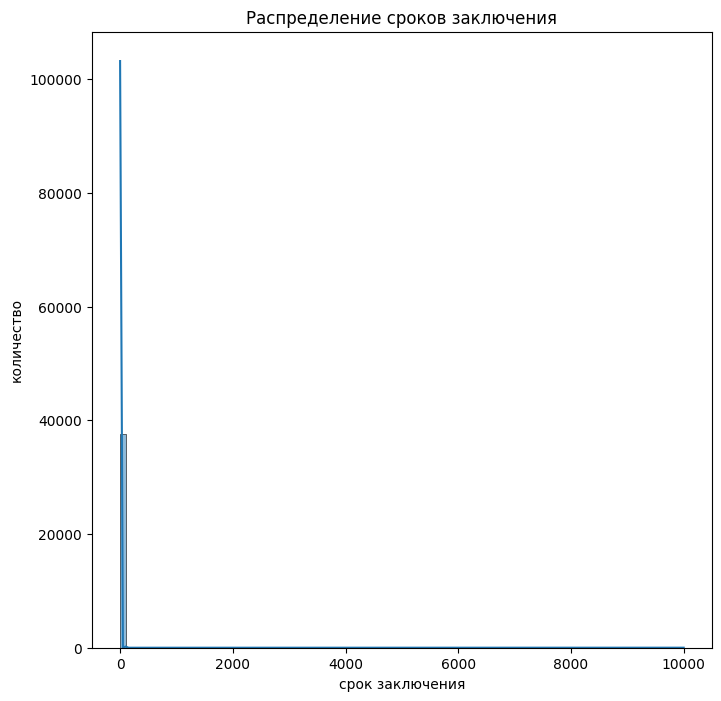

In [102]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 8))
plt.title("Распределение сроков заключения")
plt.xlabel("срок заключения")
plt.ylabel("количество")

sns.histplot(data=df["prison_term"], bins=100, kde=True, legend=False)
plt.show()

Есть пик на 9 лет, также возможные выбросы где 100 лет.

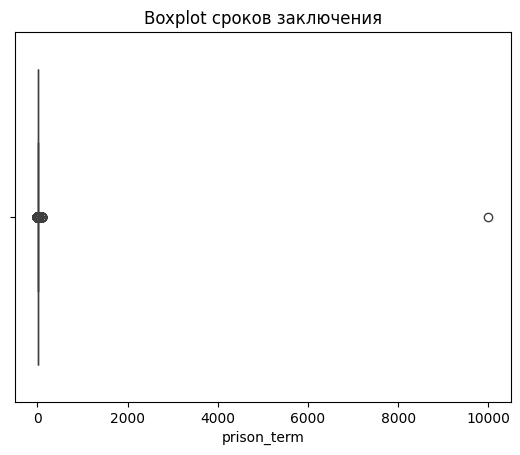

In [103]:
sns.boxplot(x=df['prison_term'])
plt.title('Boxplot сроков заключения')
plt.show()

In [104]:
Q1 = df['prison_term'].quantile(0.25)
Q3 = df['prison_term'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df['prison_term'] > lower_bound) & (df['prison_term'] < upper_bound)]
df.shape

(34462, 20)

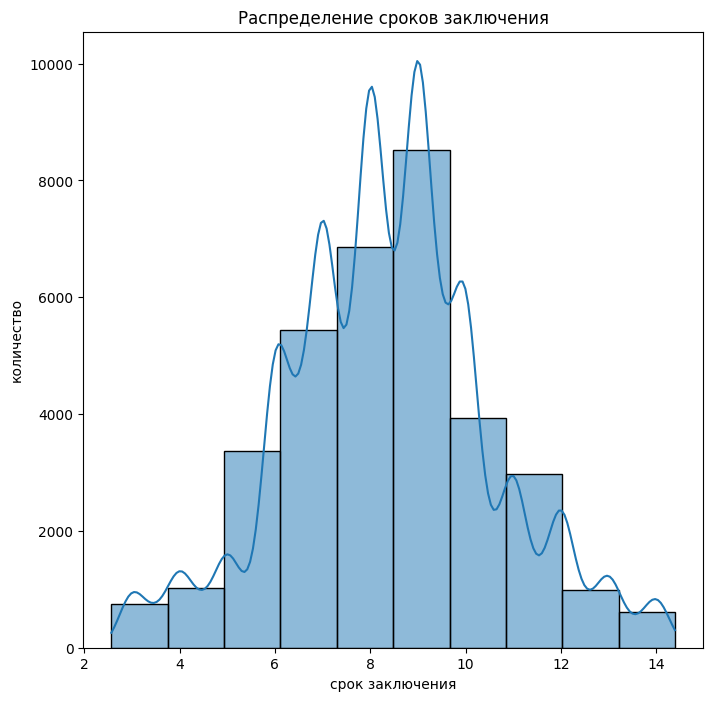

In [105]:
plt.figure(figsize=(8, 8))
plt.title("Распределение сроков заключения")
plt.xlabel("срок заключения")
plt.ylabel("количество")

sns.histplot(data=df["prison_term"], bins=10, kde=True, legend=False)
plt.show()

In [106]:
df['prison_term'].head()
df['prison_term'].describe()

count    34462.000000
mean         8.384232
std          2.151922
min          2.570000
25%          7.000000
50%          8.363707
75%          9.544859
max         14.389865
Name: prison_term, dtype: float64

In [107]:
df.columns

Index(['id', 'judge', 'decision', 'gender_accused', 'prior_convictions',
       'alcohol', 'precrime_argument', 'has_woman_victim', 'has_man_victim',
       'method', 'motive', 'location', 'prison_term', 'many_victims', 'year',
       'season', 'attempt', 'victim_child_or_helpless', 'cruel',
       'region_name'],
      dtype='object')

In [108]:
df['gender_accused'].value_counts()

gender_accused
1    28787
0     5675
Name: count, dtype: int64

In [109]:
df['prior_convictions'].value_counts()

prior_convictions
0    29408
1     5054
Name: count, dtype: int64

In [110]:
df['alcohol'].value_counts()

alcohol
1    29419
0     5043
Name: count, dtype: int64

In [111]:
df['precrime_argument'].value_counts()

precrime_argument
1    32037
0     2425
Name: count, dtype: int64

In [112]:
df['has_woman_victim'].value_counts()

has_woman_victim
0    23886
1    10576
Name: count, dtype: int64

In [113]:
df['has_man_victim'] = df['has_man_victim'].astype(int)

In [114]:
df['has_man_victim'].value_counts()

has_man_victim
1    27320
0     7142
Name: count, dtype: int64

In [115]:
df.columns

Index(['id', 'judge', 'decision', 'gender_accused', 'prior_convictions',
       'alcohol', 'precrime_argument', 'has_woman_victim', 'has_man_victim',
       'method', 'motive', 'location', 'prison_term', 'many_victims', 'year',
       'season', 'attempt', 'victim_child_or_helpless', 'cruel',
       'region_name'],
      dtype='object')

In [116]:
categorical = ['judge', 'decision','season', 'region_name']
numeric = ['year']
multilabel = ['method', 'motive', 'location']
other = ['gender_accused', 'prior_convictions', 'alcohol', 'precrime_argument', 'has_woman_victim', 'has_man_victim', 'many_victims', 'attempt', 'victim_child_or_helpless', 'cruel']

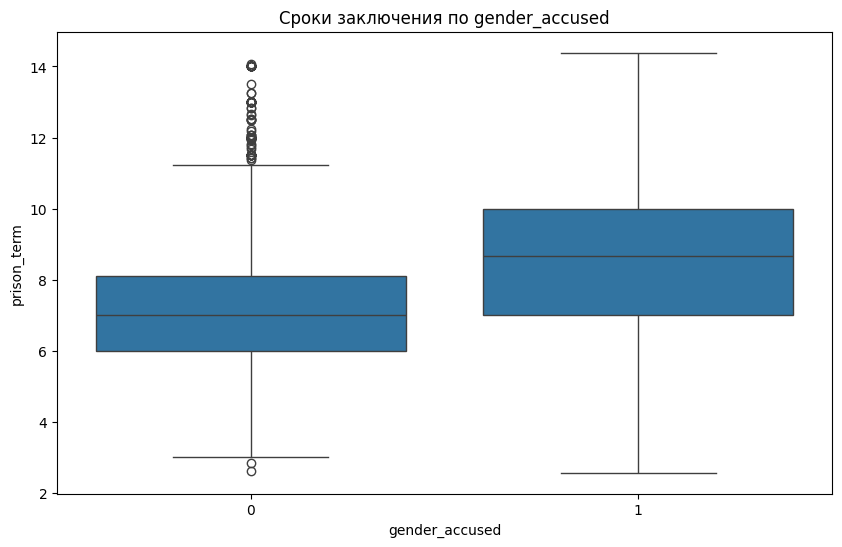

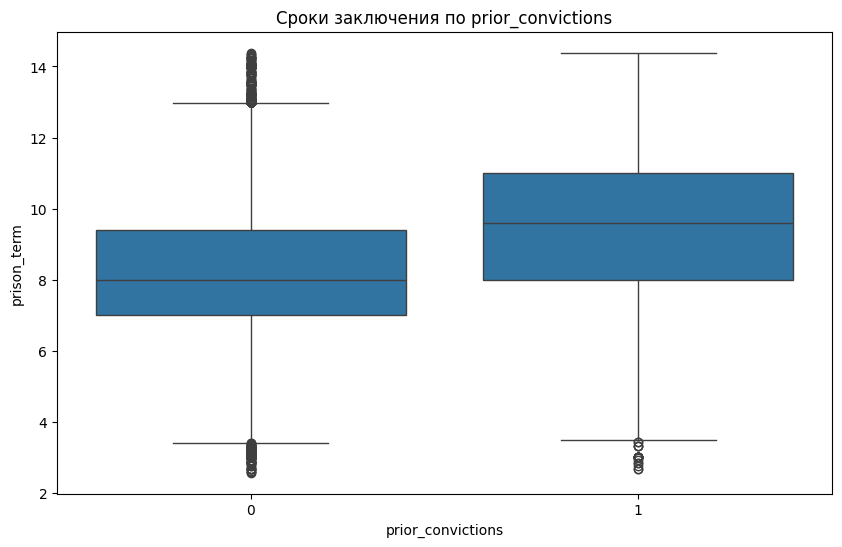

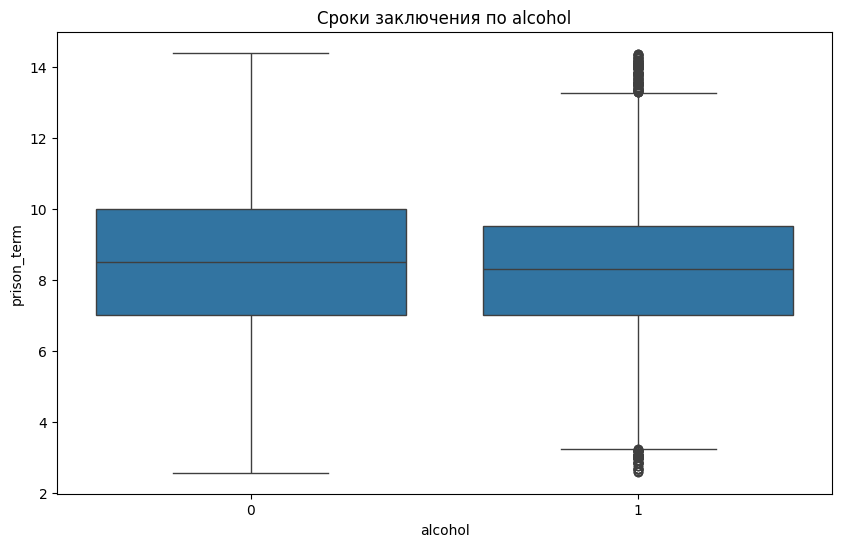

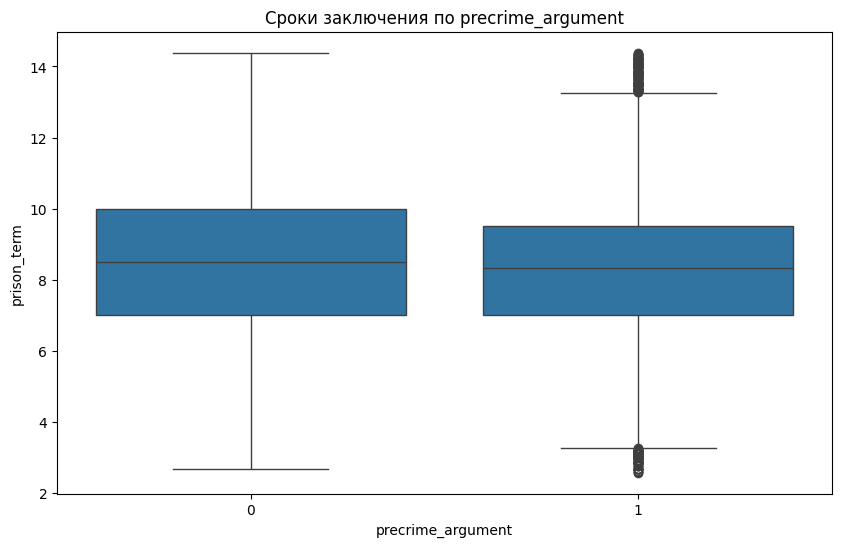

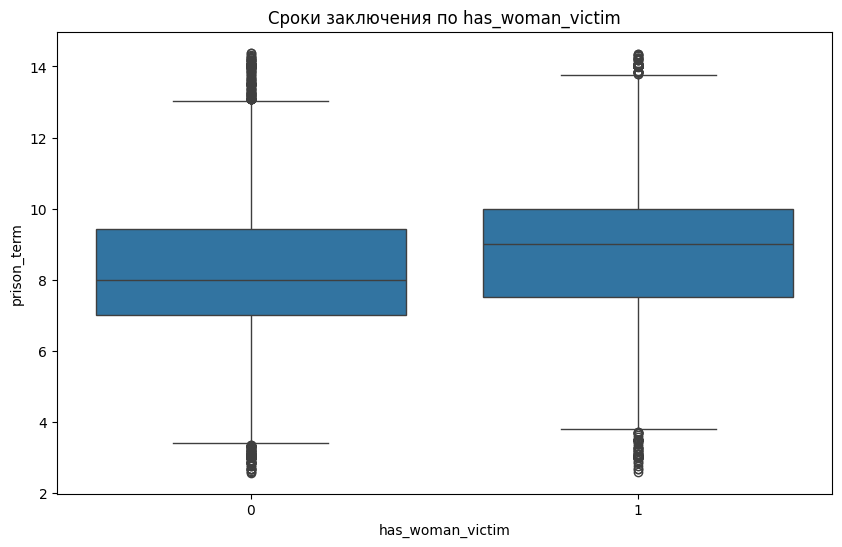

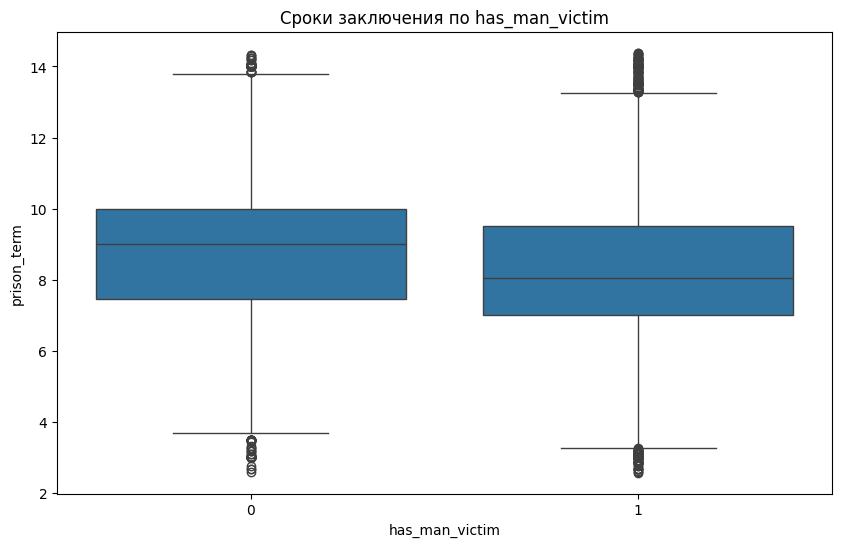

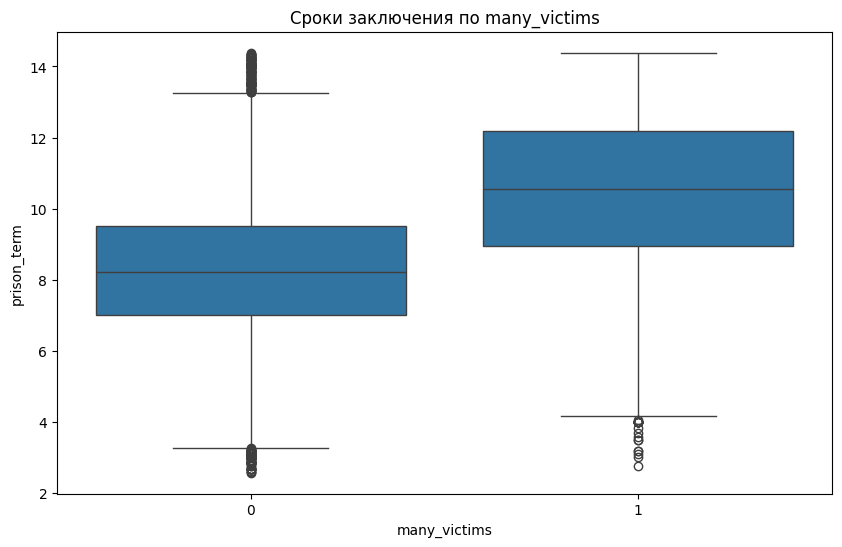

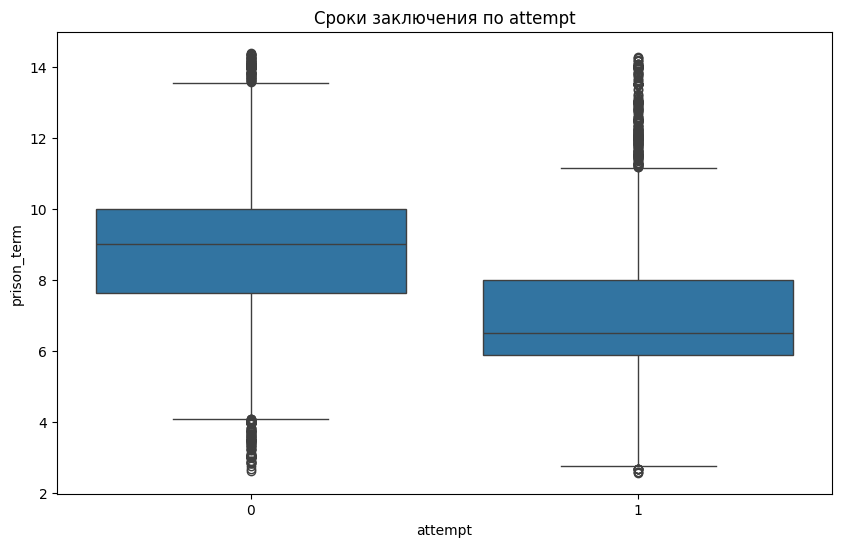

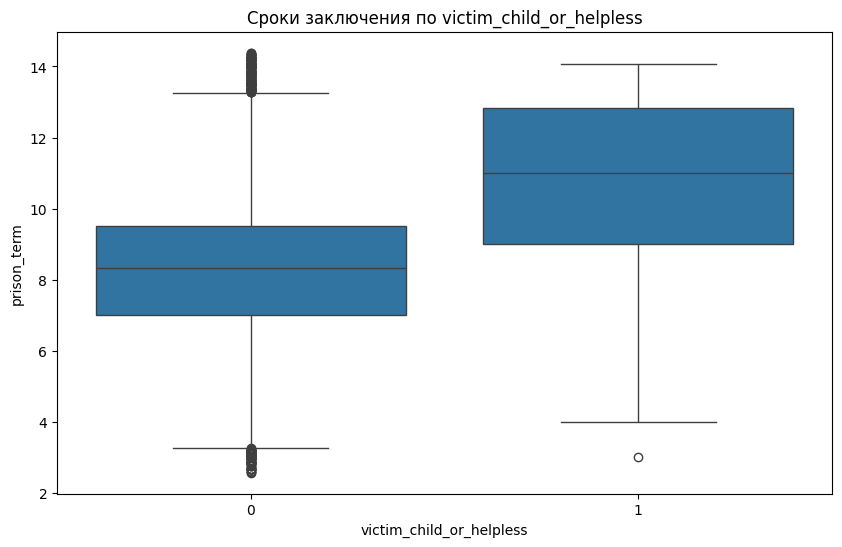

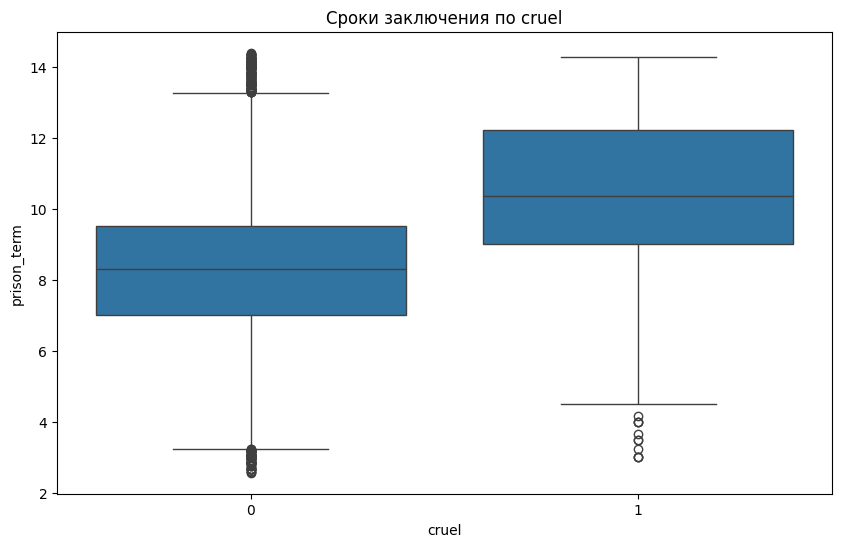

In [117]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in other:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=col, y='prison_term', data=df)
    plt.title(f"Сроки заключения по {col}")
    plt.show()

In [118]:
def group_top_categories(df, column, top_n=10, other_label='другое'):
    top_categories = df[column].value_counts().nlargest(top_n).index
    
    df[column] = df[column].apply(lambda x: x if x in top_categories else other_label)
    return df

In [119]:
df = group_top_categories(df, 'judge', top_n=8, other_label='другое судьи')
df = group_top_categories(df, 'region_name', top_n=8, other_label='другое регионы')

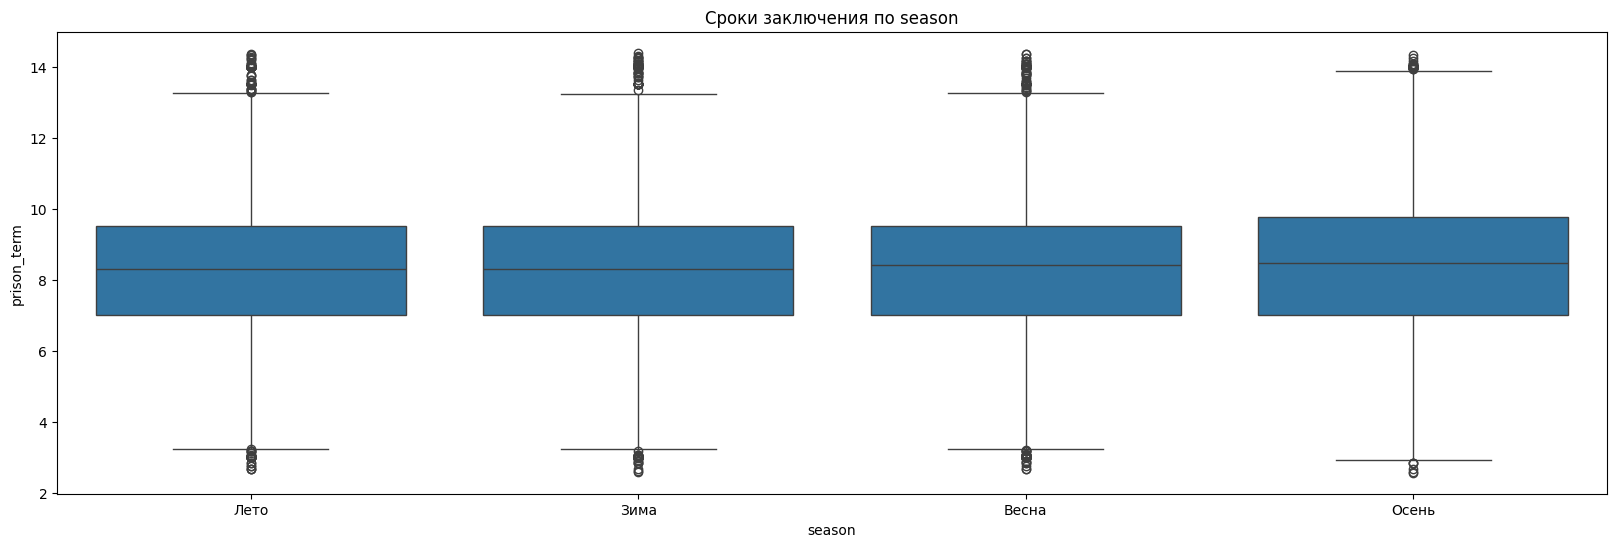

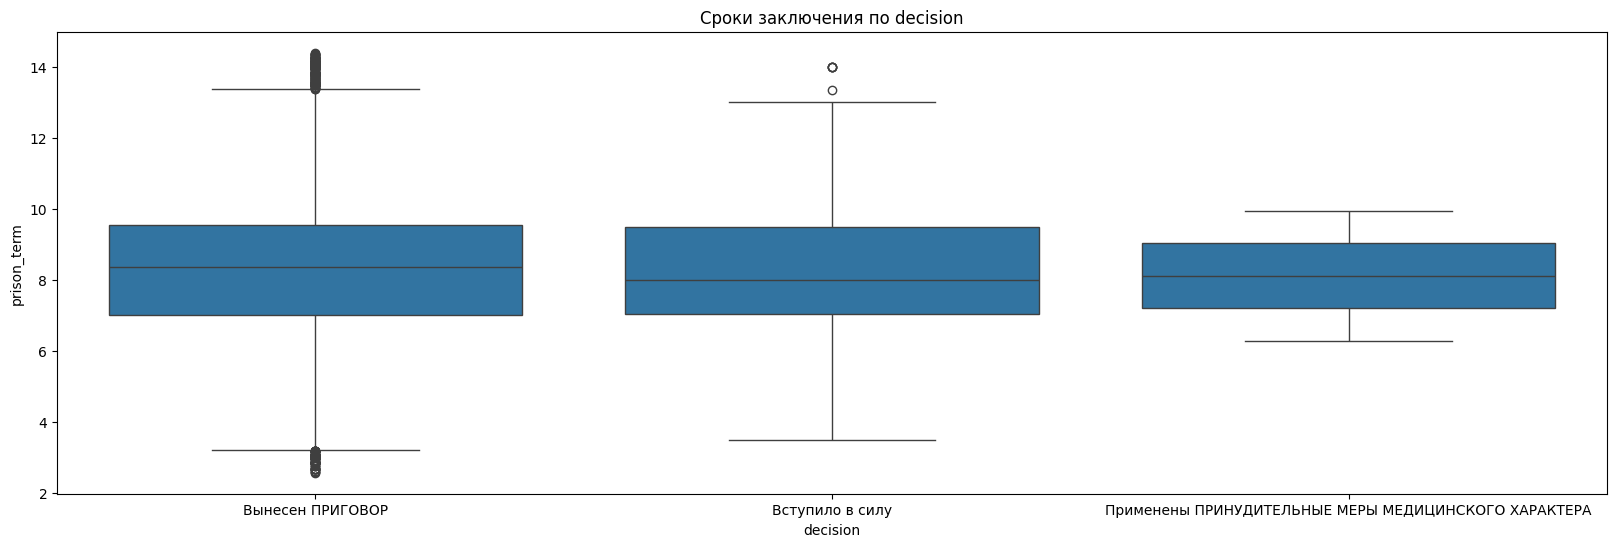

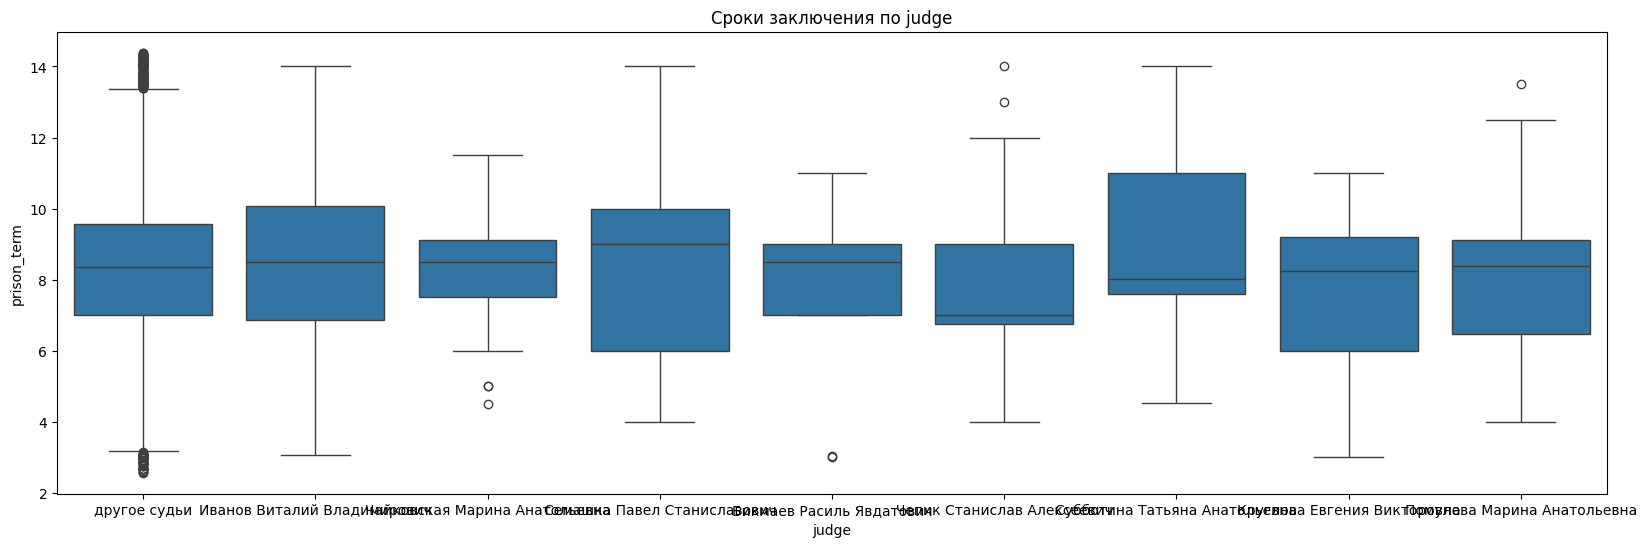

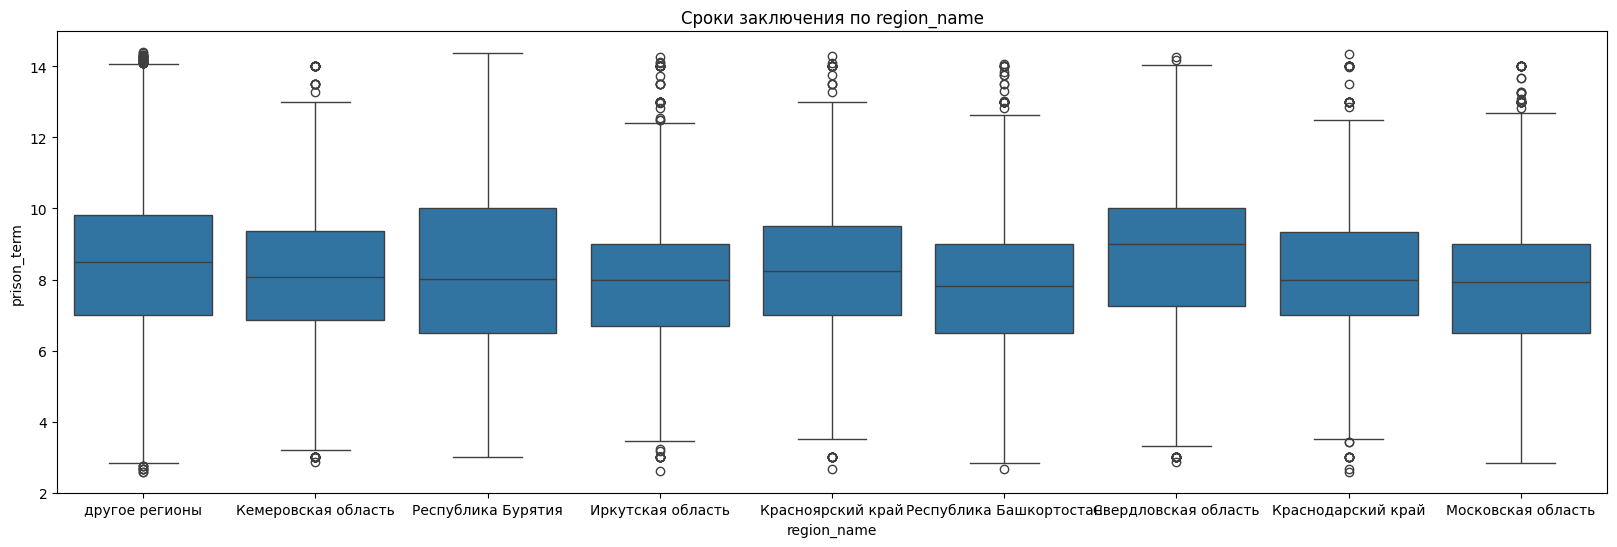

In [120]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in ['season', 'decision', 'judge', 'region_name']:
    plt.figure(figsize=(20, 6))
    sns.boxplot(x=col, y='prison_term', data=df)
    plt.title(f"Сроки заключения по {col}")
    plt.show()

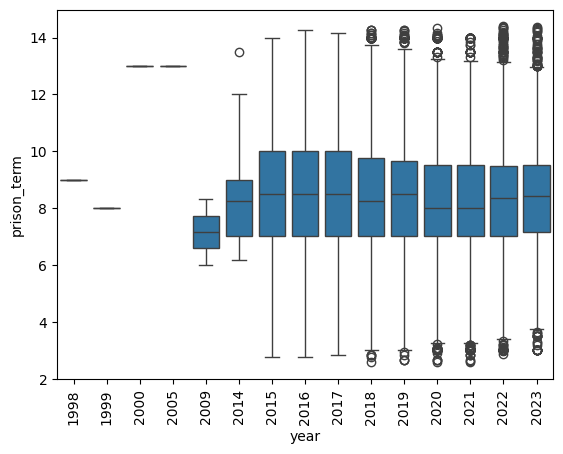

In [121]:
sns.boxplot(x='year', y='prison_term', data=df)
plt.xticks(rotation=90)
plt.show()

In [122]:
multilabel

['method', 'motive', 'location']

In [123]:
df['method'].value_counts()

method
холодное оружие                                                                              17626
физическое воздействие, холодное оружие                                                       7678
физическое воздействие                                                                        1792
огнестрельное оружие                                                                          1522
тяжелые предметы, физическое воздействие                                                      1364
удушение, физическое воздействие                                                              1104
другое                                                                                         928
тяжелые предметы                                                                               653
удушение                                                                                       641
тяжелые предметы, физическое воздействие, холодное оружие                                      333
тяж

In [124]:
motive_mapping = {
    'личная неприязнь': 'личная неприязнь',
    'неприязнь': 'личная неприязнь',
    'ссора': 'личная неприязнь',
    'обида': 'личная неприязнь',
    'злость': 'личная неприязнь',
    'агрессия': 'личная неприязнь',
    'ярость': 'личная неприязнь',
    'раздражение': 'личная неприязнь',
    'оскорбление': 'личная неприязнь',
    'ненависть': 'личная неприязнь',

    'ревность': 'ревность',
    'зависть': 'ревность',

    'месть': 'месть',

    'корысть': 'корысть',
    'имущество': 'корысть',
    'ограбление': 'корысть',
    'хищение': 'корысть',
    'кража': 'корысть',
    'деньги': 'корысть',
    'личное обогащение': 'корысть',
    'наследство': 'корысть',
    'вымогательство': 'корысть',

    'алкоголь': 'алкоголь/наркотики',
    'алкогольное опьянение': 'алкоголь/наркотики',
    'наркотики': 'алкоголь/наркотики',

    'аморальное поведение': 'аморальность',
    'аморальность': 'аморальность',
    'противоправное поведение': 'аморальность',
    'унижение': 'аморальность',
    'оскорбления': 'аморальность',

    'насилие': 'насилие',
    'половое насилие': 'насилие',
    'сексуальное домогательство': 'насилие',
    'попытка изнасилования': 'насилие',

    'неизвестно': 'прочее',
    'сострадание': 'прочее',
    'страх': 'прочее',
    'жалость': 'прочее',
    'самозащита': 'прочее',
    'защита': 'прочее',
}

def map_multiple_motives(text):
    text = str(text).lower()
    matched_categories = set()
    for keyword, group in motive_mapping.items():
        if keyword in text:
            matched_categories.add(group)
    return ', '.join(sorted(matched_categories)) if matched_categories else 'прочее'

df.loc[:, 'motive'] = df['motive'].apply(map_multiple_motives)
df['motive'].value_counts()

motive
личная неприязнь                        32521
корысть, личная неприязнь                 683
прочее                                    404
личная неприязнь, ревность                337
корысть                                   261
ревность                                  126
личная неприязнь, месть                    68
аморальность, личная неприязнь             15
аморальность                               12
месть                                      11
корысть, месть                              5
личная неприязнь, насилие                   4
алкоголь/наркотики, личная неприязнь        4
личная неприязнь, месть, ревность           3
корысть, личная неприязнь, месть            3
личная неприязнь, прочее                    2
аморальность, месть                         1
корысть, ревность                           1
месть, ревность                             1
Name: count, dtype: int64

In [125]:
df['motive'] = df['motive'].replace('другое', 'другой мотив')
df['motive'] = df['motive'].replace('корысть, другое', 'корысть, другой мотив')
df['motive'] = df['motive'].replace('личная неприязнь, другое', 'личная неприязнь, другой мотив')
df['motive'].value_counts()

motive
личная неприязнь                        32521
корысть, личная неприязнь                 683
прочее                                    404
личная неприязнь, ревность                337
корысть                                   261
ревность                                  126
личная неприязнь, месть                    68
аморальность, личная неприязнь             15
аморальность                               12
месть                                      11
корысть, месть                              5
личная неприязнь, насилие                   4
алкоголь/наркотики, личная неприязнь        4
личная неприязнь, месть, ревность           3
корысть, личная неприязнь, месть            3
личная неприязнь, прочее                    2
аморальность, месть                         1
корысть, ревность                           1
месть, ревность                             1
Name: count, dtype: int64

In [126]:
df['location'].value_counts()

location
жилое помещение                                                                                                                        25854
уличное пространство                                                                                                                    3882
жилое помещение, уличное пространство                                                                                                   1412
другое                                                                                                                                  1079
жилое помещение, подъезд и прилегающие зоны                                                                                              456
общественное место                                                                                                                       364
подъезд и прилегающие зоны                                                                                                               364
обще

In [127]:
df['location'] = df['location'].replace('другое', 'другая локация')

In [128]:
from sklearn.preprocessing import MultiLabelBinarizer
import pandas as pd

result_rows = []

for col in multilabel:
    temp_df = df.copy()
    temp_df[col] = temp_df[col].str.split(", ")

    mlb = MultiLabelBinarizer()
    col_binarized = mlb.fit_transform(temp_df[col])
    col_df = pd.DataFrame(col_binarized, columns=mlb.classes_, index=temp_df.index)

    temp_df = pd.concat([temp_df, col_df], axis=1)

    for class_name in mlb.classes_:
        mean_term = temp_df.loc[temp_df[class_name] == 1, 'prison_term'].mean()
        count = temp_df[class_name].sum()

        result_rows.append({
            'Column': col,
            'Class': class_name,
            'Mean Prison Term': round(mean_term, 2) if pd.notna(mean_term) else None,
            'Count': count
        })

result_df = pd.DataFrame(result_rows)
result_df = result_df.sort_values(by='Mean Prison Term', ascending=False).reset_index(drop=True)

print("\nСредние сроки по классам:")
print(result_df.to_string(index=False))



Средние сроки по классам:
  Column                      Class  Mean Prison Term  Count
  motive                    корысть             10.18    953
  method                   удушение              8.92   1973
location               рабочая зона              8.90    305
  method     физическое воздействие              8.84  12651
  motive               аморальность              8.79     28
  method       огнестрельное оружие              8.76   1821
location                     другое              8.75     12
  method           тяжелые предметы              8.71   2628
  method                     другое              8.64   1021
location       уличное пространство              8.64   5949
  motive                    насилие              8.62      4
  motive                      месть              8.52     92
  motive                     прочее              8.52    406
location             другая локация              8.46   1079
location         общественное место              8.42    8

In [129]:
from sklearn.preprocessing import MultiLabelBinarizer

for col in multilabel:
    df[col] = df[col].str.split(", ")
    
    mlb = MultiLabelBinarizer()
    col_binarized = mlb.fit_transform(df[col])

    col_df = pd.DataFrame(col_binarized, columns=[f"{col}_{cls}" for cls in mlb.classes_], index=df.index)

    df = pd.concat([df, col_df], axis=1)
    df = df.drop(columns=[col])

In [130]:
df

,id,judge,decision,gender_accused,prior_convictions,alcohol,precrime_argument,has_woman_victim,has_man_victim,prison_term,...,motive_прочее,motive_ревность,location_другая локация,location_другое,location_жилое помещение,location_общественное место,location_общественный транспорт,location_подъезд и прилегающие зоны,location_рабочая зона,location_уличное пространство
0,92093,другое судьи,Вынесен ПРИГОВОР,1,0,0,1,0,1,9.000000,...,0,0,0,0,0,0,0,0,1,1
1,25775,другое судьи,Вынесен ПРИГОВОР,1,0,0,0,0,1,7.986857,...,0,0,0,0,0,1,0,0,0,1
2,75488,другое судьи,Вынесен ПРИГОВОР,1,0,0,1,1,1,13.000000,...,0,0,0,0,1,0,0,0,0,0
3,126184,другое судьи,Вынесен ПРИГОВОР,0,0,1,1,0,1,13.000000,...,0,0,0,0,0,0,0,0,0,1
4,102316,другое судьи,Вынесен ПРИГОВОР,1,0,0,1,1,0,8.311355,...,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37562,107387,другое судьи,Вынесен ПРИГОВОР,1,0,1,1,0,1,11.000000,...,0,0,0,0,1,0,0,0,0,0
37564,6580,другое судьи,Вынесен ПРИГОВОР,1,0,1,1,0,1,9.000000,...,0,0,0,0,1,0,0,0,0,0
37565,62712,другое судьи,Вынесен ПРИГОВОР,1,0,1,1,1,0,9.000000,...,0,1,0,0,1,0,0,0,0,0
37566,54534,другое судьи,Вынесен ПРИГОВОР,1,0,1,0,1,1,3.830000,...,0,1,0,0,1,0,0,0,0,0


In [131]:
df.columns

Index(['id', 'judge', 'decision', 'gender_accused', 'prior_convictions',
       'alcohol', 'precrime_argument', 'has_woman_victim', 'has_man_victim',
       'prison_term', 'many_victims', 'year', 'season', 'attempt',
       'victim_child_or_helpless', 'cruel', 'region_name', 'method_другое',
       'method_огнестрельное оружие', 'method_тяжелые предметы',
       'method_удушение', 'method_физическое воздействие',
       'method_холодное оружие', 'motive_алкоголь/наркотики',
       'motive_аморальность', 'motive_корысть', 'motive_личная неприязнь',
       'motive_месть', 'motive_насилие', 'motive_прочее', 'motive_ревность',
       'location_другая локация', 'location_другое',
       'location_жилое помещение', 'location_общественное место',
       'location_общественный транспорт',
       'location_подъезд и прилегающие зоны', 'location_рабочая зона',
       'location_уличное пространство'],
      dtype='object')

In [132]:
df1 = pd.read_csv('df_labeled_all_1.csv')
df = df[~df['id'].isin(df1['id'])]
df.shape

(28609, 39)

In [133]:
# df['attempt_x_prior_convictions'] = df['remainder__attempt'] * df['remainder__prior_convictions']
# df['cruelty_x_child_victim'] = df['remainder__cruel'] * df['remainder__victim_child_or_helpless']

In [134]:
# df['severity_score'] = (
#     df['remainder__cruel'] * 2 
#     + df['remainder__many_victims'] * 1.5 
#     + df['remainder__method_физическое воздейщение'] * 1.2
# )

In [138]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import optuna

target_col = 'prison_term'

# categorical_features = ['decision', 'season', 'year', 'judge', 'region_name']
# other_features = [
#     'gender_accused', 'prior_convictions', 'alcohol', 'precrime_argument',
#     'has_woman_victim', 'has_man_victim', 'many_victims', 'attempt',
#     'victim_child_or_helpless', 'cruel',
    
#     'method_другое',
#     'method_огнестрельное оружие', 'method_тяжелые предметы',
#     'method_удушение', 'method_физическое воздействие',
#     'method_холодное оружие',
    
#     'motive_алкоголь/наркотики',
#     'motive_аморальность', 'motive_корысть', 'motive_личная неприязнь',
#     'motive_месть', 'motive_насилие', 'motive_прочее', 'motive_ревность',
    
#     'location_другое', 'location_жилое помещение',
#     'location_общественное место', 'location_общественный транспорт',
#     'location_подъезд и прилегающие зоны', 'location_рабочая зона',
#     'location_уличное пространство'
# ]

categorical_features = []
other_features = [
    'gender_accused', 'prior_convictions',
    'has_woman_victim', 'many_victims', 'attempt',
    'victim_child_or_helpless', 'cruel',
    
    'method_другое',
    'method_огнестрельное оружие', 'method_тяжелые предметы',
    'method_удушение', 'method_физическое воздействие',
    'method_холодное оружие',
    
    'motive_алкоголь/наркотики',
    'motive_аморальность', 'motive_корысть', 'motive_личная неприязнь',
    'motive_месть', 'motive_насилие', 'motive_прочее', 'motive_ревность',
    
    'location_другое', 'location_жилое помещение',
    'location_общественное место', 'location_общественный транспорт',
    'location_подъезд и прилегающие зоны', 'location_рабочая зона',
    'location_уличное пространство'
]

selected_features = categorical_features + other_features

X = df[selected_features]
y = df[target_col]

In [139]:
X_test_val, X_train, y_test_val, y_train = train_test_split(
    X, y, 
    test_size=0.6, 
    random_state=42
)

X_test, X_val, y_test, y_val = train_test_split(
    X_test_val, y_test_val, 
    test_size=0.5, 
    random_state=42
)

In [140]:
X_train.shape, X_val.shape, X_test.shape    

((14570, 28), (4857, 28), (4856, 28))

In [141]:
column_transformer = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
], remainder='passthrough')


X_rf_train = column_transformer.fit_transform(X_train)
X_rf_val = column_transformer.transform(X_val)
X_rf_test = column_transformer.transform(X_test)
feature_names_rf = column_transformer.get_feature_names_out()

X_cb_train, X_cb_val, X_cb_test = X_train, X_val, X_test

In [142]:
df[target_col].describe()

count    24283.000000
mean         8.209901
std          1.487143
min          5.000000
25%          7.000000
50%          8.000000
75%          9.080000
max         11.000000
Name: prison_term, dtype: float64

In [144]:
correlation = df.corr()['prison_term'].sort_values(ascending=False)
print(correlation.head(20))

ValueError: could not convert string to float: 'другое судьи'

In [143]:
from optuna.importance import get_param_importances

def train_random_forest(X_train, y_train, X_val, y_val, X_test, y_test):
    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
            'max_depth': trial.suggest_int('max_depth', 20, 30),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
            'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
            'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),
            'random_state': 42,
            'n_jobs': -1
        }
        model = RandomForestRegressor(**params)
        model.fit(X_train, y_train)
        val_pred = model.predict(X_val)
        return r2_score(y_val, val_pred)

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=5)

    best_params = study.best_params
    print("Best RF Params")
    print(best_params)

    # importance = get_param_importances(study)
    # print("\nHyperparameter Importance for Random Forest")
    # for k, v in importance.items():
    #     print(f"{k}: {v:.4f}")

    final_model = RandomForestRegressor(**best_params, random_state=42, n_jobs=-1)
    final_model.fit(
        np.vstack([X_train, X_val]),
        np.hstack([y_train, y_val])
    )
    test_pred = final_model.predict(X_test)

    print("\nRandom Forest Results")
    print('MAE:', mean_absolute_error(y_test, test_pred))
    print('MSE:', mean_squared_error(y_test, test_pred))
    print('R2:', r2_score(y_test, test_pred))

    importances = final_model.feature_importances_
    feature_importance = pd.DataFrame({
        'Feature': feature_names_rf,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)

    df['error'] = abs(test_pred - y_test)
    high_error_cases = df[df['error'] > 5]
    print(high_error_cases['prison_term'])

    return final_model, feature_importance

rf_model, rf_importance = train_random_forest(X_rf_train, y_train, X_rf_val, y_val, X_rf_test, y_test)
print("\nRandom Forest Top 10")
print(rf_importance.head(10))

[I 2025-04-29 01:49:45,690] A new study created in memory with name: no-name-e36b8d26-a31a-4200-b1e4-4b67bdb166ea
[I 2025-04-29 01:49:46,389] Trial 0 finished with value: 0.27182931196631255 and parameters: {'n_estimators': 407, 'max_depth': 30, 'min_samples_split': 9, 'min_samples_leaf': 5, 'max_features': 'log2', 'bootstrap': False}. Best is trial 0 with value: 0.27182931196631255.
[I 2025-04-29 01:49:47,740] Trial 1 finished with value: 0.2709618614470678 and parameters: {'n_estimators': 473, 'max_depth': 26, 'min_samples_split': 16, 'min_samples_leaf': 4, 'max_features': 'log2', 'bootstrap': True}. Best is trial 0 with value: 0.27182931196631255.
[I 2025-04-29 01:49:49,080] Trial 2 finished with value: 0.2754216364712473 and parameters: {'n_estimators': 829, 'max_depth': 24, 'min_samples_split': 15, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'bootstrap': False}. Best is trial 2 with value: 0.2754216364712473.
[I 2025-04-29 01:49:49,317] Trial 3 finished with value: 0.277653529

Best RF Params
{'n_estimators': 119, 'max_depth': 25, 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'log2', 'bootstrap': False}

Random Forest Results
MAE: 1.0389306452783278
MSE: 1.6275623432210238
R2: 0.27439625972713855
Series([], Name: prison_term, dtype: float64)

Random Forest Top 10
                                     Feature  Importance
4                         remainder__attempt    0.490346
0                  remainder__gender_accused    0.201627
1               remainder__prior_convictions    0.102504
11  remainder__method_физическое воздействие    0.041992
3                    remainder__many_victims    0.040093
2                remainder__has_woman_victim    0.038370
15                 remainder__motive_корысть    0.016170
12         remainder__method_холодное оружие    0.011412
6                           remainder__cruel    0.007236
22       remainder__location_жилое помещение    0.007205


In [ ]:
cv fbgnh

SyntaxError: invalid syntax (790489183.py, line 1)

In [ ]:
target_col = 'prison_term'

categorical_features = []
other_features = [
    'gender_accused', 'prior_convictions',
    'has_woman_victim', 'many_victims', 'attempt',
    'victim_child_or_helpless', 'cruel',
    'физическое воздействие',
    'корысть', 'личная неприязнь'
]

selected_features = categorical_features + other_features

X = df[selected_features]
y = df[target_col]

X_test_val, X_train, y_test_val, y_train = train_test_split(
    X, y, 
    test_size=0.7, 
    random_state=42
)

X_test, X_val, y_test, y_val = train_test_split(
    X_test_val, y_test_val, 
    test_size=0.5, 
    random_state=42
)

column_transformer = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
], remainder='passthrough')


X_rf_train = column_transformer.fit_transform(X_train)
X_rf_val = column_transformer.transform(X_val)
X_rf_test = column_transformer.transform(X_test)
feature_names_rf = column_transformer.get_feature_names_out()

X_cb_train, X_cb_val, X_cb_test = X_train, X_val, X_test

rf_model, rf_importance = train_random_forest(X_rf_train, y_train, X_rf_val, y_val, X_rf_test, y_test)
print("\nRandom Forest Top 10")
print(rf_importance.head(10))

[I 2025-04-27 16:41:01,999] A new study created in memory with name: no-name-8240098f-2d3f-4733-8b03-92e0dccba978
[I 2025-04-27 16:41:02,967] Trial 0 finished with value: 1.2432032834983244 and parameters: {'n_estimators': 895, 'max_depth': 3, 'min_samples_split': 12, 'min_samples_leaf': 4, 'max_features': 'log2', 'bootstrap': False}. Best is trial 0 with value: 1.2432032834983244.
[I 2025-04-27 16:41:03,730] Trial 1 finished with value: 1.1388054802510628 and parameters: {'n_estimators': 301, 'max_depth': 7, 'min_samples_split': 20, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 1 with value: 1.1388054802510628.
[I 2025-04-27 16:41:05,280] Trial 2 finished with value: 1.1299640546871774 and parameters: {'n_estimators': 897, 'max_depth': 8, 'min_samples_split': 11, 'min_samples_leaf': 6, 'max_features': None, 'bootstrap': False}. Best is trial 2 with value: 1.1299640546871774.
[I 2025-04-27 16:41:06,050] Trial 3 finished with value: 1.1310261750657766 

Best RF Params
{'n_estimators': 852, 'max_depth': 27, 'min_samples_split': 16, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'bootstrap': True}

Random Forest Results
MAE: 1.1089369513342748
MSE: 2.2756929188255763
R2: 0.4080424550921341

Random Forest Top 10
                               Feature  Importance
8                   remainder__корысть    0.221403
4                   remainder__attempt    0.174135
3              remainder__many_victims    0.168491
1         remainder__prior_convictions    0.149025
0            remainder__gender_accused    0.130674
6                     remainder__cruel    0.036985
9          remainder__личная неприязнь    0.036586
2          remainder__has_woman_victim    0.032592
5  remainder__victim_child_or_helpless    0.031049
7    remainder__физическое воздействие    0.019060


In [ ]:
def train_catboost(X_train, y_train, X_val, y_val, X_test, y_test):
    def objective(trial):
        params = {
            'iterations': trial.suggest_int('iterations', 500, 1500),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'depth': trial.suggest_int('depth', 4, 10),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-3, 10, log=True),
            'random_strength': trial.suggest_float('random_strength', 0.1, 10),
            'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
            'grow_policy': trial.suggest_categorical('grow_policy', ['SymmetricTree', 'Depthwise', 'Lossguide'])
        }
        model = CatBoostRegressor(
            **params,
            cat_features=categorical_features,
            verbose=0
        )
        model.fit(
            X_train, y_train,
            eval_set=(X_val, y_val),
            early_stopping_rounds=50
        )
        val_pred = model.predict(X_val)
        return mean_absolute_error(y_val, val_pred)

    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=10)

    best_params = study.best_params
    print("\nBest CatBoost Params")
    print(best_params)

    # importance = get_param_importances(study)
    # print("\nHyperparameter Importance for CatBoost")
    # for k, v in importance.items():
    #     print(f"{k}: {v:.4f}")

    final_model = CatBoostRegressor(
        **best_params,
        cat_features=categorical_features,
        verbose=100
    )
    final_model.fit(
        pd.concat([X_train, X_val]),
        pd.concat([y_train, y_val]),
        early_stopping_rounds=50
    )
    test_pred = final_model.predict(X_test)

    print("\nCatBoost Results")
    print('MAE:', mean_absolute_error(y_test, test_pred))
    print('MSE:', mean_squared_error(y_test, test_pred))
    print('R2:', r2_score(y_test, test_pred))

    feature_importance = pd.DataFrame({
        'Feature': X_train.columns.tolist(),
        'Importance': final_model.get_feature_importance()
    }).sort_values(by='Importance', ascending=False)

    return final_model, feature_importance

cat_model, cat_importance = train_catboost(X_cb_train, y_train, X_cb_val, y_val, X_cb_test, y_test)

print("\nCatBoost Top 10")
print(cat_importance.head(10))

[I 2025-04-27 15:45:38,913] A new study created in memory with name: no-name-c529fb1e-7444-4a49-85ee-0bd239339f43
[I 2025-04-27 15:45:45,938] Trial 0 finished with value: 1.117248603366309 and parameters: {'iterations': 618, 'learning_rate': 0.22828745612312082, 'depth': 8, 'l2_leaf_reg': 2.4530303950370485, 'random_strength': 0.8554308370813754, 'bagging_temperature': 0.47440570244789537, 'grow_policy': 'Depthwise'}. Best is trial 0 with value: 1.117248603366309.
[I 2025-04-27 15:46:51,028] Trial 1 finished with value: 1.1162848033102202 and parameters: {'iterations': 580, 'learning_rate': 0.02601439567208215, 'depth': 9, 'l2_leaf_reg': 0.019531502251002787, 'random_strength': 6.656564943575863, 'bagging_temperature': 0.5183979209502446, 'grow_policy': 'Depthwise'}. Best is trial 1 with value: 1.1162848033102202.
[I 2025-04-27 15:47:49,693] Trial 2 finished with value: 1.1170814851475486 and parameters: {'iterations': 994, 'learning_rate': 0.024567165223710635, 'depth': 8, 'l2_leaf_re


Best CatBoost Params
{'iterations': 580, 'learning_rate': 0.02601439567208215, 'depth': 9, 'l2_leaf_reg': 0.019531502251002787, 'random_strength': 6.656564943575863, 'bagging_temperature': 0.5183979209502446, 'grow_policy': 'Depthwise'}

Hyperparameter Importance for CatBoost
bagging_temperature: 0.5055
learning_rate: 0.2251
random_strength: 0.0975
l2_leaf_reg: 0.0699
grow_policy: 0.0550
depth: 0.0248
iterations: 0.0221
0:	learn: 1.9887971	total: 102ms	remaining: 58.8s
100:	learn: 1.5120480	total: 10.2s	remaining: 48.2s
200:	learn: 1.4793829	total: 20.6s	remaining: 38.9s
300:	learn: 1.4704677	total: 30.7s	remaining: 28.4s
400:	learn: 1.4647266	total: 41.1s	remaining: 18.4s
500:	learn: 1.4430836	total: 53.2s	remaining: 8.39s
579:	learn: 1.4146602	total: 1m 3s	remaining: 0us

CatBoost Results
MAE: 1.0909168740827904
MSE: 2.199230169655774
R2: 0.4279320899813709

CatBoost Top 10
                     Feature  Importance
21                   корысть   22.968267
12                   attempt

In [ ]:
FVGBHFNJ

NameError: name 'FVGBHFNJ' is not defined

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import optuna

# ===================== Параметры =====================
target_col = 'prison_term'

categorical_features = ['decision', 'season', 'year', 'judge', 'region_name']
other_features = ['gender_accused', 'prior_convictions', 'alcohol', 'precrime_argument',
                  'has_woman_victim', 'has_man_victim', 'many_victims', 'attempt',
                  'victim_child_or_helpless', 'cruel', 'огнестрельное оружие',
                  'тяжелые предметы', 'удушение', 'физическое воздействие',
                  'холодное оружие', 'другой мотив', 'корысть', 'личная неприязнь',
                  'ревность', 'другая локация', 'жилое помещение',
                  'общественное место', 'общественный транспорт', 'подъезд и прилегающие зоны',
                  'рабочая зона', 'уличное пространство']

# Какие фичи использовать сейчас
selected_features = categorical_features + other_features

# ===================== Подготовка данных =====================
X = df[selected_features]
y = df[target_col]

column_transformer = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
    ('passthrough', 'passthrough', other_features)
])

X_transformed = column_transformer.fit_transform(X)
feature_names = column_transformer.get_feature_names_out()

X_train_val, X_test, y_train_val, y_test = train_test_split(X_transformed, y, test_size=0.1, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.1, random_state=42)

# ===================== Обучение моделей =====================

def train_random_forest(X_train, y_train, X_val, y_val, X_test, y_test):
    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
            'max_depth': trial.suggest_int('max_depth', 3, 30),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 4),
            'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
            'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),
            'random_state': 42
        }
        model = RandomForestRegressor(**params)
        model.fit(X_train, y_train)
        val_pred = model.predict(X_val)
        return mean_absolute_error(y_val, val_pred)

    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=5)

    best_params = study.best_params
    final_model = RandomForestRegressor(**best_params, random_state=42)
    final_model.fit(X_train_val, y_train_val)
    test_pred = final_model.predict(X_test)

    print("\n=== Random Forest Results ===")
    print('MAE:', mean_absolute_error(y_test, test_pred))
    print('MSE:', mean_squared_error(y_test, test_pred))
    print('R2:', r2_score(y_test, test_pred))

    importances = final_model.feature_importances_
    feature_importance = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)

    return final_model, feature_importance

def train_catboost(X_train, y_train, X_val, y_val, X_test, y_test):
    def objective(trial):
        params = {
            'iterations': trial.suggest_int('iterations', 500, 1500),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'depth': trial.suggest_int('depth', 4, 10),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-3, 10, log=True),
            'random_strength': trial.suggest_float('random_strength', 0.1, 10),
            'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
            'grow_policy': trial.suggest_categorical('grow_policy', ['SymmetricTree', 'Depthwise', 'Lossguide']),
        }
        train_pool = Pool(X_train, y_train)
        val_pool = Pool(X_val, y_val)
        model = CatBoostRegressor(**params, verbose=0)
        model.fit(train_pool, eval_set=val_pool, early_stopping_rounds=50)
        val_pred = model.predict(val_pool)
        return mean_absolute_error(y_val, val_pred)

    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=5)

    best_params = study.best_params
    final_model = CatBoostRegressor(**best_params, verbose=100)
    final_model.fit(X_train_val, y_train_val)

    test_pred = final_model.predict(X_test)

    print("\n=== CatBoost Results ===")
    print('MAE:', mean_absolute_error(y_test, test_pred))
    print('MSE:', mean_squared_error(y_test, test_pred))
    print('R2:', r2_score(y_test, test_pred))

    feature_importance = pd.DataFrame({
        'Feature': feature_names,
        'Importance': final_model.get_feature_importance()
    }).sort_values(by='Importance', ascending=False)

    return final_model, feature_importance

# ===================== Запуск =====================
rf_model, rf_importance = train_random_forest(X_train, y_train, X_val, y_val, X_test, y_test)
cat_model, cat_importance = train_catboost(X_train, y_train, X_val, y_val, X_test, y_test)

# ===================== Важность признаков =====================
print("\n=== Random Forest Feature Importance ===")
print(rf_importance.head(10))

print("\n=== CatBoost Feature Importance ===")
print(cat_importance.head(10))


[I 2025-04-27 14:42:42,087] A new study created in memory with name: no-name-c729b6d2-6d4a-4d69-a395-e430f2f23b33
[I 2025-04-27 14:42:45,495] Trial 0 finished with value: 1.2799396970333519 and parameters: {'n_estimators': 732, 'max_depth': 4, 'min_samples_split': 8, 'min_samples_leaf': 2, 'max_features': 'log2', 'bootstrap': False}. Best is trial 0 with value: 1.2799396970333519.
[I 2025-04-27 14:42:47,961] Trial 1 finished with value: 1.1170327294120128 and parameters: {'n_estimators': 226, 'max_depth': 13, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 1 with value: 1.1170327294120128.
[I 2025-04-27 14:42:55,076] Trial 2 finished with value: 1.1161525512912076 and parameters: {'n_estimators': 396, 'max_depth': 30, 'min_samples_split': 3, 'min_samples_leaf': 3, 'max_features': 'log2', 'bootstrap': False}. Best is trial 2 with value: 1.1161525512912076.
[I 2025-04-27 14:43:01,264] Trial 3 finished with value: 1.1242109645266547


=== Random Forest Results ===
MAE: 1.0884785991161616
MSE: 2.172988536757528
R2: 0.43129377210377207


[I 2025-04-27 14:45:08,227] Trial 0 finished with value: 1.1158953154640248 and parameters: {'iterations': 1284, 'learning_rate': 0.25360495499648333, 'depth': 5, 'l2_leaf_reg': 0.0010331168246069365, 'random_strength': 7.86973896134107, 'bagging_temperature': 0.21195198709157392, 'grow_policy': 'Depthwise'}. Best is trial 0 with value: 1.1158953154640248.
[I 2025-04-27 14:45:17,164] Trial 1 finished with value: 1.1070911450178456 and parameters: {'iterations': 1199, 'learning_rate': 0.017190886896545646, 'depth': 8, 'l2_leaf_reg': 0.01190436296044349, 'random_strength': 6.323194269140612, 'bagging_temperature': 0.842952841400946, 'grow_policy': 'Depthwise'}. Best is trial 1 with value: 1.1070911450178456.
[I 2025-04-27 14:45:18,381] Trial 2 finished with value: 1.1129105094619787 and parameters: {'iterations': 1418, 'learning_rate': 0.24522725691861696, 'depth': 6, 'l2_leaf_reg': 0.018950109147898606, 'random_strength': 9.792773873950793, 'bagging_temperature': 0.028810849470217725, '

0:	learn: 1.9895315	total: 5.9ms	remaining: 3.1s
100:	learn: 1.5038818	total: 577ms	remaining: 2.42s
200:	learn: 1.4661860	total: 1.16s	remaining: 1.88s
300:	learn: 1.4514657	total: 1.77s	remaining: 1.32s
400:	learn: 1.4402487	total: 2.35s	remaining: 732ms
500:	learn: 1.4303487	total: 2.95s	remaining: 147ms
525:	learn: 1.4277857	total: 3.09s	remaining: 0us

=== CatBoost Results ===
MAE: 1.0745117609269994
MSE: 2.1291214961387612
R2: 0.44277448577403167

=== Random Forest Feature Importance ===
                                  Feature  Importance
57                   passthrough__корысть    0.144874
42         passthrough__prior_convictions    0.133697
48                   passthrough__attempt    0.131019
47              passthrough__many_victims    0.129413
41            passthrough__gender_accused    0.101641
45          passthrough__has_woman_victim    0.040393
58          passthrough__личная неприязнь    0.040341
54    passthrough__физическое воздействие    0.034775
49  passthrough

In [ ]:
cat_features = [
    'judge', 'decision', 'gender_accused', 'prior_convictions',
    'alcohol', 'precrime_argument', 'has_woman_victim', 'has_man_victim',
    'many_victims', 'year', 'season', 'attempt',
    'victim_child_or_helpless', 'cruel', 'region_name', 'другое',
    'огнестрельное оружие', 'тяжелые предметы', 'удушение',
    'физическое воздействие', 'холодное оружие', 'другой мотив', 'корысть',
    'личная неприязнь', 'ревность', 'другая локация', 'жилое помещение',
    'общественное место', 'общественный транспорт',
    'подъезд и прилегающие зоны', 'рабочая зона', 'уличное пространство'
]

In [ ]:
C VGFBHG

SyntaxError: invalid syntax (2965960798.py, line 1)

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(['id', 'prison_term'], axis=1)
y = df['prison_term']


X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, 
    test_size=0.1, 
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, 
    test_size=0.1, 
    random_state=42
)

In [ ]:
import optuna
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_absolute_error

def objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 500, 1500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'depth': trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-3, 10, log=True),
        'random_strength': trial.suggest_float('random_strength', 0.1, 10),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
        'grow_policy': trial.suggest_categorical('grow_policy', ['SymmetricTree', 'Depthwise', 'Lossguide']),
        'cat_features': cat_features
    }
    
    train_pool = Pool(X_train, y_train, cat_features=cat_features)
    val_pool = Pool(X_val, y_val, cat_features=cat_features)

    model = CatBoostRegressor(**params, verbose=0)
    model.fit(train_pool, eval_set=val_pool, early_stopping_rounds=50)

    val_pred = model.predict(val_pool)
    mae = mean_absolute_error(y_val, val_pred)
    
    return mae

In [ ]:
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=5)

[I 2025-04-26 23:19:25,044] A new study created in memory with name: no-name-8d9f29d5-4449-46cb-864b-f7a8343cf22b
[I 2025-04-26 23:21:23,542] Trial 0 finished with value: 1.0879237401637092 and parameters: {'iterations': 1330, 'learning_rate': 0.011257724695285003, 'depth': 4, 'l2_leaf_reg': 4.654822748883735, 'random_strength': 7.101867650851287, 'bagging_temperature': 0.4552673493227941, 'grow_policy': 'Lossguide'}. Best is trial 0 with value: 1.0879237401637092.
[I 2025-04-26 23:24:02,185] Trial 1 finished with value: 1.086414409459307 and parameters: {'iterations': 1275, 'learning_rate': 0.055699447267442186, 'depth': 8, 'l2_leaf_reg': 0.3438336285382803, 'random_strength': 6.095409954388605, 'bagging_temperature': 0.4606648173169925, 'grow_policy': 'Lossguide'}. Best is trial 1 with value: 1.086414409459307.
[I 2025-04-26 23:24:21,604] Trial 2 finished with value: 1.0854610200216228 and parameters: {'iterations': 1208, 'learning_rate': 0.05696621013329152, 'depth': 7, 'l2_leaf_reg

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

best_params = study.best_params

final_train_pool = Pool(X_train_val, y_train_val, cat_features=cat_features)

final_model = CatBoostRegressor(**best_params, verbose=100)
final_model.fit(final_train_pool)

test_pool = Pool(X_test, cat_features=cat_features)
test_pred = final_model.predict(test_pool)

print('MAE:', mean_absolute_error(y_test, test_pred))
print('MSE:', mean_squared_error(y_test, test_pred))
print('R2:', r2_score(y_test, test_pred))

0:	learn: 1.9683859	total: 56.7ms	remaining: 1m 8s
100:	learn: 1.4743649	total: 6.06s	remaining: 1m 6s
200:	learn: 1.4559902	total: 12.3s	remaining: 1m 1s
300:	learn: 1.4226391	total: 20.1s	remaining: 1m
400:	learn: 1.4024385	total: 27.6s	remaining: 55.6s
500:	learn: 1.3856402	total: 34s	remaining: 48s
600:	learn: 1.3718159	total: 40.8s	remaining: 41.3s
700:	learn: 1.3597951	total: 46.7s	remaining: 33.8s
800:	learn: 1.3488641	total: 52.6s	remaining: 26.7s
900:	learn: 1.3363912	total: 58.9s	remaining: 20.1s
1000:	learn: 1.3274325	total: 1m 4s	remaining: 13.4s
1100:	learn: 1.3163892	total: 1m 10s	remaining: 6.87s
1200:	learn: 1.3087864	total: 1m 16s	remaining: 448ms
1207:	learn: 1.3078993	total: 1m 17s	remaining: 0us
MAE: 1.0703797816785827
MSE: 2.1050680745158137
R2: 0.44906965505255714


In [ ]:
feature_importance = final_model.get_feature_importance(prettified=True)
print(feature_importance.head(10))

          Feature Id  Importances
0            корысть    20.280622
1       many_victims    14.019411
2            attempt    13.836021
3  prior_convictions    11.550383
4     gender_accused    10.162762
5              judge     7.073807
6        region_name     4.952709
7              cruel     2.511332
8               year     1.769785
9   has_woman_victim     1.724004


In [ ]:
optuna.visualization.plot_optimization_history(study)
optuna.visualization.plot_param_importances(study)

In [ ]:
DSVFDBRG

NameError: name 'DSVFDBRG' is not defined

In [ ]:
# X = df.drop(['prison_term', 'id'], axis=1)
# y = df['prison_term']

In [ ]:
# cat_features = [
#     'judge', 'decision', 'gender_accused', 'prior_convictions',
#     'alcohol', 'precrime_argument', 'has_woman_victim', 'has_man_victim',
#     'many_victims', 'year', 'season', 'attempt',
#     'victim_child_or_helpless', 'cruel', 'region_name', 'другое',
#     'огнестрельное оружие', 'тяжелые предметы', 'удушение',
#     'физическое воздействие', 'холодное оружие', 'другой мотив', 'корысть',
#     'личная неприязнь', 'ревность', 'другая локация', 'жилое помещение',
#     'общественное место', 'общественный транспорт',
#     'подъезд и прилегающие зоны', 'рабочая зона', 'уличное пространство'
# ]

In [ ]:
X = df.drop(['prison_term', 'id'], axis=1)
y = df['prison_term']

In [ ]:
# categorical = ['judge', 'decision','season', 'region_name', 'year']
categorical = ['decision', 'season', 'year']
other = ['gender_accused', 'prior_convictions', 'alcohol',
         'precrime_argument', 'has_woman_victim', 'has_man_victim',
         'many_victims', 'attempt', 'victim_child_or_helpless', 'cruel',
         'огнестрельное оружие', 'тяжелые предметы', 'удушение',
        'физическое воздействие', 'холодное оружие', 'другой мотив', 'корысть',
        'личная неприязнь', 'ревность', 'другая локация', 'жилое помещение',
        'общественное место', 'общественный транспорт',
        'подъезд и прилегающие зоны', 'рабочая зона', 'уличное пространство'
         ]

In [ ]:
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import pandas as pd


# class MultiLabelBinarizerTransformer(BaseEstimator, TransformerMixin):
#     def __init__(self):
#         self.encoders = {}
    
#     def fit(self, X, y=None):
#         for col in X.columns:
#             mlb = MultiLabelBinarizer()
#             mlb.fit(X[col])
#             self.encoders[col] = mlb
#         return self

#     def transform(self, X):
#         transformed = []
#         for col in X.columns:
#             print(col)
#             binarized = self.encoders[col].transform(X[col])
#             binarized_df = pd.DataFrame(binarized, columns=[f"{col}__{c}" for c in self.encoders[col].classes_], index=X.index)
#             transformed.append(binarized_df)
#         return pd.concat(transformed, axis=1)

column_transformer = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical),
    # ('scaling', StandardScaler(), numeric),
    # ('multilabel', MultiLabelBinarizerTransformer(), multilabel),
    ('passthrough', 'passthrough', other)
])

X_transformed = column_transformer.fit_transform(X)

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import optuna

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_transformed, y, 
    test_size=0.1, 
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, 
    test_size=0.1, 
    random_state=42
)

In [ ]:

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 4),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),
        'random_state': 42
    }
    
    model = RandomForestRegressor(**params)
    model.fit(X_train, y_train)
    
    val_pred = model.predict(X_val)
    mae = mean_absolute_error(y_val, val_pred)
    
    return mae

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=5)

# Обучение финальной модели
best_params = study.best_params
final_model = RandomForestRegressor(**best_params, random_state=42)
final_model.fit(X_train_val, y_train_val)

# Оценка на тестовых данных
test_pred = final_model.predict(X_test)

print('MAE:', mean_absolute_error(y_test, test_pred))
print('MSE:', mean_squared_error(y_test, test_pred))
print('R2:', r2_score(y_test, test_pred))

# Важность признаков
importances = final_model.feature_importances_
# Получаем имена признаков после трансформации
feature_names = column_transformer.get_feature_names_out()

# Дальше строим DataFrame
feature_importance_rf = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)


# Визуализация оптимизации
optuna.visualization.plot_optimization_history(study)
optuna.visualization.plot_param_importances(study)

[I 2025-04-27 14:14:41,267] A new study created in memory with name: no-name-e7fdf8fa-6b42-488f-afe0-e67856cc990d
[I 2025-04-27 14:14:54,800] Trial 0 finished with value: 1.2451567759889497 and parameters: {'n_estimators': 168, 'max_depth': 22, 'min_samples_split': 6, 'min_samples_leaf': 2, 'max_features': None, 'bootstrap': False}. Best is trial 0 with value: 1.2451567759889497.
[I 2025-04-27 14:15:47,660] Trial 1 finished with value: 1.1795990086700592 and parameters: {'n_estimators': 952, 'max_depth': 23, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': None, 'bootstrap': True}. Best is trial 1 with value: 1.1795990086700592.
[I 2025-04-27 14:16:11,876] Trial 2 finished with value: 1.1958191500075441 and parameters: {'n_estimators': 366, 'max_depth': 18, 'min_samples_split': 8, 'min_samples_leaf': 3, 'max_features': None, 'bootstrap': False}. Best is trial 1 with value: 1.1795990086700592.
[I 2025-04-27 14:16:19,540] Trial 3 finished with value: 1.124027808011238 and p

MAE: 1.0980086303208065
MSE: 2.2082334437120688
R2: 0.42206961019605227


In [ ]:
feature_importance_rf

,Feature,Importance
39,passthrough__корысть,0.149681
30,passthrough__attempt,0.134654
24,passthrough__prior_convictions,0.133036
29,passthrough__many_victims,0.131264
23,passthrough__gender_accused,0.106448
40,passthrough__личная неприязнь,0.040113
27,passthrough__has_woman_victim,0.037995
36,passthrough__физическое воздействие,0.034648
32,passthrough__cruel,0.031717
31,passthrough__victim_child_or_helpless,0.029421
